## Visualizar las habilidades óptimas para aprender cómo Data Analysy

In [ ]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast 
import locale

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

In [ ]:
df_DA = df_DA.dropna(subset=['salary_year_avg'])

df_DA_exploded = df_DA.explode('job_skills')

df_DA_exploded['job_skills'] = df_DA_exploded['job_skills'].str.capitalize()

df_DA_exploded[['salary_year_avg', 'job_skills']].head(5)

In [ ]:
df_DA_skills = df_DA_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

DA_job_count = len(df_DA)

df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / DA_job_count * 100

df_DA_skills

In [ ]:
skill_percent = 5

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]

df_DA_skills_high_demand

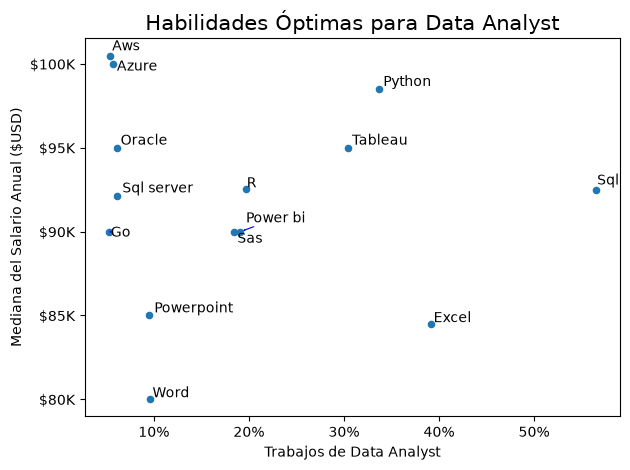

In [20]:
from adjustText import adjust_text

df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')

texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt.capitalize()))

plt.xlabel('Trabajos de Data Analyst')
plt.ylabel('Mediana del Salario Anual ($USD)')
plt.title('Habilidades Óptimas para Data Analyst', fontsize=15)

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='b', lw='0.8'))

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()